In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

numeric_columns = ["video_streaming_hours_per_week", "gaming_hours_per_week","avg_screen_on_hours_per_day"]

data  = pd.read_excel("clean_data.xlsx")
my_columns = numeric_columns

In [2]:
print("Missing Values")
missing = data[my_columns].isnull().sum()
print(missing)
if missing.sum() == 0:
    print("\nNo missing values.")
else:
    pct_missing = (missing / len(data) * 100).round(2)
    print("\nPercent missing:")
    print(pct_missing)

print("\nData Types")
print(data[my_columns].dtypes)

print("\nSummary Stats (numeric columns)")
print(data[numeric_columns].describe())

Missing Values
video_streaming_hours_per_week    0
gaming_hours_per_week             0
avg_screen_on_hours_per_day       0
dtype: int64

No missing values.

Data Types
video_streaming_hours_per_week    float64
gaming_hours_per_week             float64
avg_screen_on_hours_per_day       float64
dtype: object

Summary Stats (numeric columns)
       video_streaming_hours_per_week  gaming_hours_per_week  \
count                     5000.000000            5000.000000   
mean                        10.020740               4.012920   
std                          4.990648               2.834289   
min                          0.000000               0.000000   
25%                          6.600000               1.900000   
50%                         10.000000               3.300000   
75%                         13.400000               5.400000   
max                         27.200000              24.800000   

       avg_screen_on_hours_per_day  
count                  5000.000000  
mean    

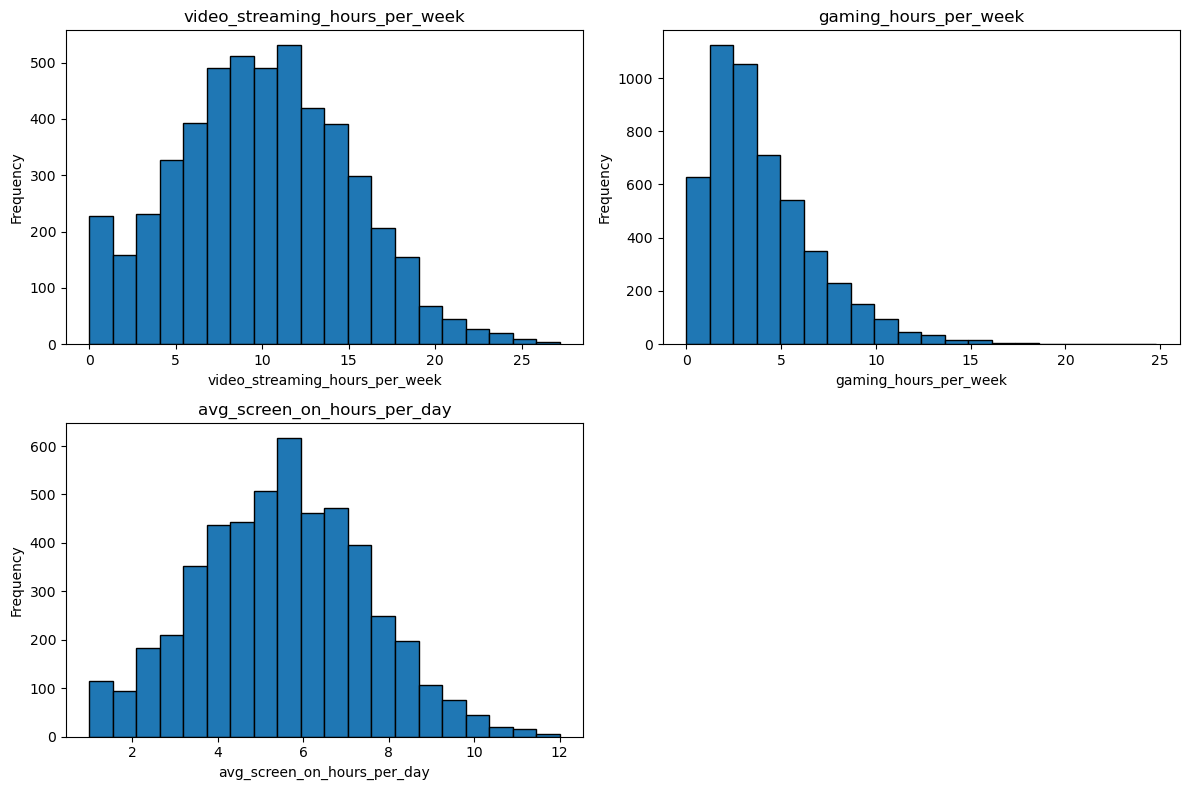

In [3]:
if numeric_columns:
    n = len(numeric_columns)
    nrows = (n + 1) // 2
    fig, axes = plt.subplots(nrows, 2, figsize=(12, 4 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(numeric_columns):
        axes[i].hist(data[col], bins=20, edgecolor="black")
        axes[i].set_title(col)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    for i in range(n, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

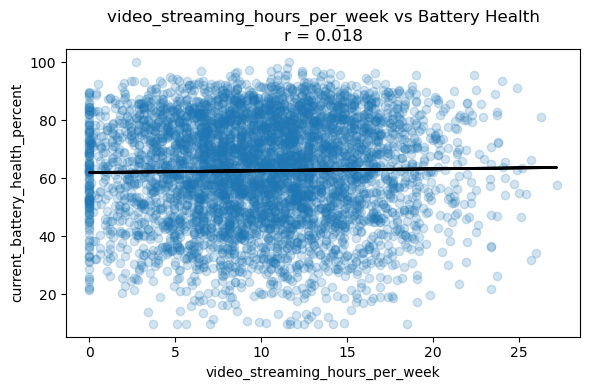

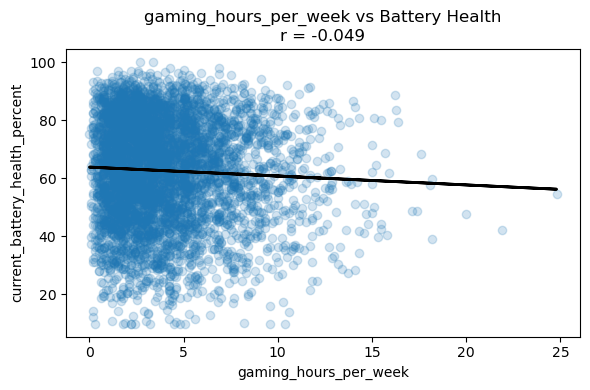

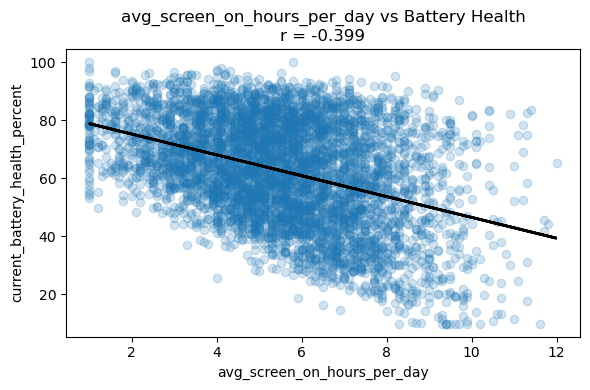

In [4]:
target = "current_battery_health_percent"

for col in numeric_columns:
    x = data[col]
    y = data[target]

    plt.figure(figsize=(6, 4))
    plt.scatter(x, y, alpha=0.2)

    r = x.corr(y)

    m, b = np.polyfit(x, y, 1)
    plt.plot(x, m * x + b, color="black", linewidth=2)

    plt.title(f"{col} vs Battery Health\nr = {r:.3f}")
    plt.xlabel(col)
    plt.ylabel(target)
    plt.tight_layout()
    plt.show()